# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

---

# Analysis of Apartment Listings

You are provided with data from the Yandex Real Estate service — an archive of apartment sale listings in Saint Petersburg and nearby localities collected over several years. Your task is to learn how to determine the market value of real estate properties. To do this, conduct an exploratory data analysis and identify the parameters that influence property prices. This will allow you to build an automated system capable of detecting anomalies and fraudulent activity.

For each apartment listed for sale, two types of data are available. The first type is entered by users, while the second type is obtained automatically based on cartographic data. For example, the distance to the city center, the airport, and other objects is automatically calculated using geolocation services. The number of parks and bodies of water is also filled in automatically without user involvement.

### 1. Откройте файл с данными и изучите общую информацию

### 1. Open the dataset file and examine the general information

In [1]:
#Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Прочитаем файл и сохраним его в переменную
try:
    data = pd.read_csv('/Users/danielschollenberg/Desktop/real_estate_data.csv', sep="\t")
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep="\t")

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

None

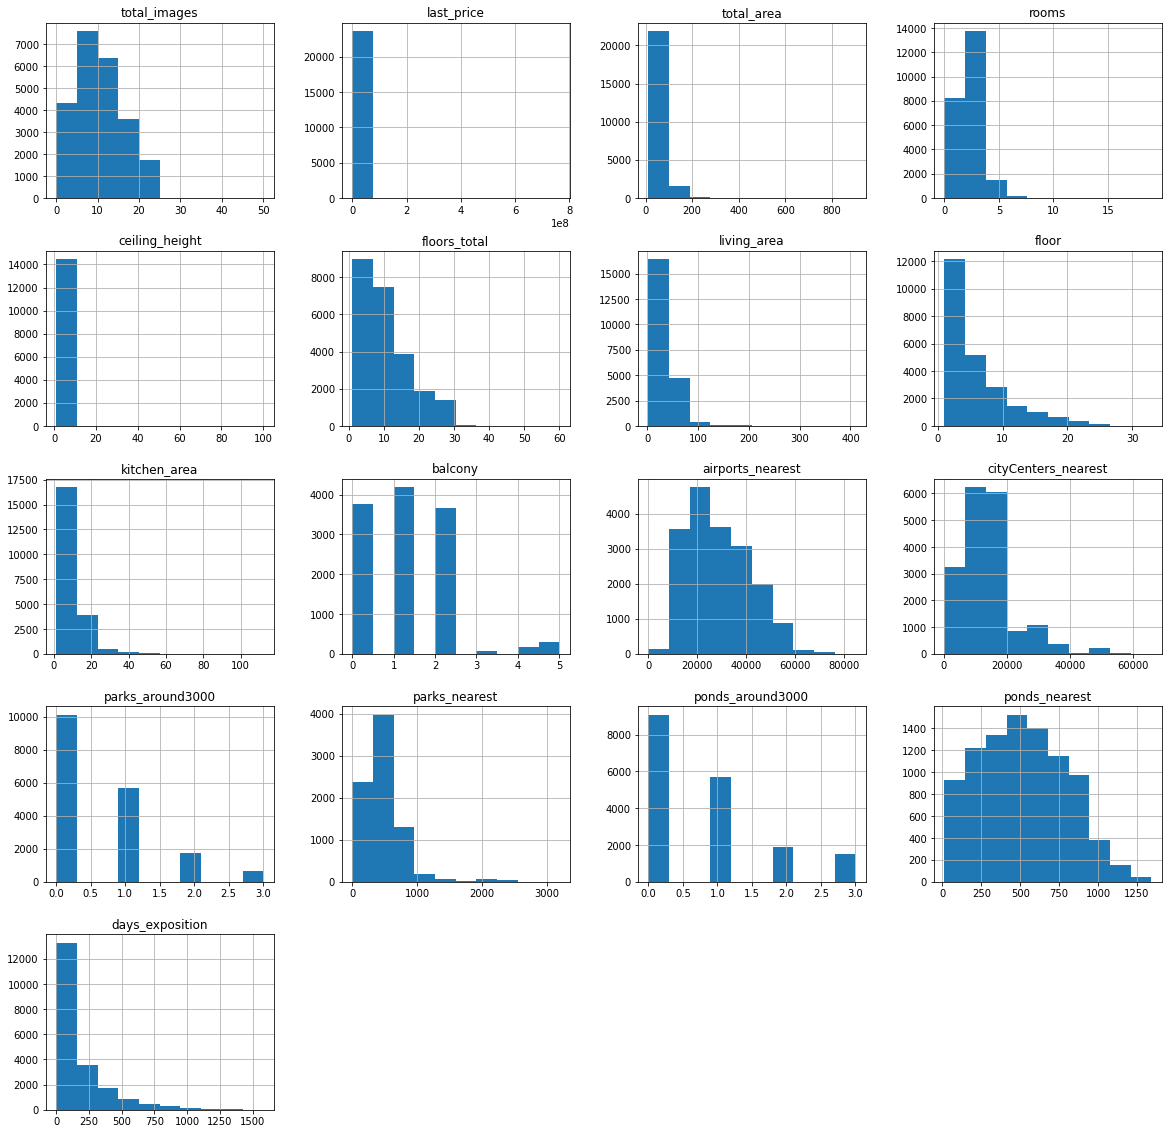

In [3]:
#Изучим датасет
display(data.head(10))
display(data.info())
data.hist(figsize=(20, 20));

#### Вывод:
- В датасете есть пропущенные значения.
- Всего 21 столбец и 23699 строк.
- Распределение на некоторых гистрограммах выглядит неестественно, похоже на присутствие аномалий или ошибок в данных. Например гистрограммы: 'last_price', 'total_area', 'ceiling_height'.

---

#### Conclusion:
- The dataset contains missing values.
- The dataset includes 21 columns and 23,699 rows.
- The distribution in some histograms appears unusual, suggesting the presence of anomalies or potential errors in the data. Examples include the histograms for: `last_price`, `total_area`, and `ceiling_height`.

### 2. Выполните предобработку данных

### 2. Perform data preprocessing

#### 2.1 Устраним пропуски

#### 2.1 Handle missing values

In [4]:
#Посчитаем количество и процент пропусков в столбцах.
#Для этого создадим датафрейм, столбцами которого будут две series с подсчётом количества и процента пропусков
#в столбцах исходного датафрейма, а названиями индексов будут названия столбцов исходного д.ф..
#Чтобы не создавать лишний переменных сразу выведем получившийся датафрейм
display(
    pd.DataFrame({'Количество пропусков': data.isnull().sum(), 'Процент Пропусков': round(data.isnull().mean() * 100,2)})
       )

,Количество пропусков,Процент Пропусков
total_images,0,0.00
last_price,0,0.00
total_area,0,0.00
first_day_exposition,0,0.00
rooms,0,0.00
ceiling_height,9195,38.80
floors_total,86,0.36
living_area,1903,8.03
floor,0,0.00
is_apartment,20924,88.29


##### Опишем столбцы с пропусками и возможные причины их возникновения:
- 'ceiling_height' = высота потолков (м) - около 38 % значений в этом столбце пропущено, весьма много. Видимо данное значение указывается пользователем по усмотрению, и причина пропусков здесь, что пользователи решают не указывать значение, а система не требует обязательного заполнения. Вообще, высота потолков - это значение, имеющие некий, весьма четкий диапазон, и чаще всего, в квартирах, это значение - около 2.5 - 3 метров. Заполнить пропуск здесь, вероятно, можно - средним значением - на датасет в целом, среднее будет влиять меньше медианы, но прежде, чем это делать, нужно оценить есть ли аномалии, чтобы они не искажали среднее значение.

- 'floors_total' = количество этажей - доля пропущенных значений крайне мала, менее 0,5% строк имеют пропуск, потребности в замени пропусков в этом столбце - нет, их влияние на датасет в целом - сведено к минимуму. Впрочем, логичной замены, вероятнее всего, найти тоже не получится, - количество этажей в разных домах, и разных городах, - будет сильно отличаться - ни медиана, ни среднее - не подойдут. Возможно, имело бы смысл отгруппировать дома по их типу и городу, - в таком случае, верояно, медиана, или скорее среднее - подошли бы, но в нашей ситуации - с таким маленьким количеством пропусков - это смысла не имеет - пропуски оставляем как есть. Причин пропусков может быть две:  
1. Значение указывается пользователем по усмотрению, аналогично столбцу 'ceiling_height'. Однако это маловероятно, так как разница в количестве пропущенных значений между столбцами очень большая.  
2. Более вероятно, что система автоматически заполняет количество этажей дома на основе данных онлайн-карт после определения адреса объекта. Пользователь вводит адрес, система сопоставляет его с картографическими сервисами и автоматически заполняет дополнительные параметры объекта, включая 'floors_total'. Ошибки могут возникать как из-за сбоев самой системы, так и из-за неточностей в источниках данных (например, картографических сервисах).

- 'living_area' = жилая площадь — доля пропущенных значений мала. Площадь может значительно отличаться от объекта к объекту и, вероятно, указывается пользователем по усмотрению. Не вижу необходимости заполнять пропуски — оставляем их.

- 'is_apartment' = является ли объект апартаментами — очень большая доля пропусков, более 70%. Нельзя однозначно интерпретировать пропуск как значение "нет", поэтому любое заполнение может привести к искажению результатов. Пропуски лучше оставить как есть. Вероятно, значение заполняется пользователем по желанию.

- 'kitchen_area' = площадь кухни — ситуация похожа на 'living_area': значения могут сильно отличаться между объектами, а доля пропусков невелика. Однако возможно, что пропуск означает отсутствие кухни. Чтобы принять решение о заполнении пропусков, нужно дополнительно проверить значения общей площади и тип объекта для строк с пропусками в 'kitchen_area'. Пока пропуски оставляем.

- 'balcony' = количество балконов — вероятно, если продавец не указал число балконов, значит их нет. Такие пропуски можно заменить на 0. Значение, скорее всего, вводится пользователем. Возможный способ предотвращения пропусков в будущем — сделать поле обязательным, предлагая выбрать "нет" или указать количество балконов.

- 'locality_name' = название населённого пункта — доля пропусков мала. Определить населённый пункт при отсутствии значения, скорее всего, невозможно, поэтому пропуски оставляем. Вероятно, значение вводится пользователем, после чего система автоматически определяет дополнительные параметры объекта. Возможные причины пропусков:  
1. Пользователь не указал населённый пункт.  
2. Ошибка системы сбора данных, из-за которой введённые значения не были сохранены.  
3. Проблемы с картографическими сервисами, которые не смогли определить населённый пункт.  

- 'airports_nearest' = расстояние до ближайшего аэропорта (м) — пропуски можно интерпретировать как слишком большое расстояние до аэропорта или отсутствие аэропорта поблизости. Если бы переменная была категориальной, можно было бы заменить пропуски значением "больше максимального расстояния". Однако это количественная переменная, поэтому пропуски оставляем. Вероятно, система заполняет это значение автоматически на основе картографических данных.

- 'cityCenters_nearest' = расстояние до центра города (м) — ситуация похожа на предыдущую переменную. Возможно, центр города невозможно определить для некоторых населённых пунктов, либо система не может сопоставить введённый адрес с картографическими данными. Пропуски оставляем.

- 'parks_around3000' = число парков в радиусе 3 км — если значение пропущено, вероятно, парков поблизости нет. Пропуски можно заменить на 0.

- 'parks_nearest' = расстояние до ближайшего парка (м) — аналогичная ситуация с 'airports_nearest'. Пропуски оставляем.

- 'ponds_around3000' = число водоёмов в радиусе 3 км — аналогично 'parks_around3000' и 'balcony', пропуски можно заменить на 0.

- 'ponds_nearest' = расстояние до ближайшего водоёма (м) — аналогично другим столбцам с расстояниями, пропуски оставляем.

- 'days_exposition' = сколько дней было размещено объявление (от публикации до снятия) — если значение пропущено, скорее всего объявление ещё активно. Логичной замены пропуска нет, поэтому оставляем их как есть, учитывая при анализе, что пропуск означает "объявление ещё не закрыто".

---

##### Description of columns with missing values and possible reasons for their occurrence:

- **'ceiling_height'** — ceiling height (m). About 38% of the values are missing, which is quite high. This value is likely entered manually by users, and many may choose not to provide it since the field is not mandatory. Typically, ceiling height in apartments falls within a fairly narrow range, around 2.5–3 meters. In theory, missing values could be filled with the mean value for the dataset. However, before doing so, it is necessary to check for anomalies that could distort the average.

- **'floors_total'** — total number of floors in the building. The share of missing values is extremely small (less than 0.5%). Their influence on the dataset is minimal, so replacing them is unnecessary. Moreover, a logical replacement is difficult because the number of floors varies significantly across buildings and cities. Possible reasons for missing values include user omission or errors in the automated system that retrieves building information from online maps.

- **'living_area'** — living area. The share of missing values is small. Since living area can vary greatly between properties and is likely entered manually by users, there is no strong need to replace missing values.

- **'is_apartment'** — whether the property is an apartment unit. More than 70% of values are missing. It is not safe to assume that missing values mean “no,” so replacing them could distort the results. Therefore, missing values should be left unchanged.

- **'kitchen_area'** — kitchen area. The situation is similar to 'living_area': values vary significantly between properties, and the proportion of missing values is relatively small. In some cases, missing values might indicate the absence of a kitchen. Additional analysis is required before deciding how to handle these values.

- **'balcony'** — number of balconies. If the seller did not specify this value, it is likely that the apartment has no balconies. Therefore, missing values can reasonably be replaced with 0.

- **'locality_name'** — name of the locality. The share of missing values is small, and it is difficult to determine the correct value without additional information. Missing values should therefore remain unchanged. Possible causes include user omission or system errors during data collection.

- **'airports_nearest'** — distance to the nearest airport (m). Missing values likely indicate that the nearest airport is very far away or absent in the vicinity. Since this variable is quantitative, the missing values should be left unchanged.

- **'cityCenters_nearest'** — distance to the city center (m). The issue is similar to the airport distance variable. The system may not be able to determine the city center for certain locations or match the address with map data.

- **'parks_around3000'** — number of parks within a 3 km radius. Missing values likely mean that there are no parks nearby, so they can be replaced with 0.

- **'parks_nearest'** — distance to the nearest park (m). Similar to 'airports_nearest'; missing values should remain unchanged.

- **'ponds_around3000'** — number of ponds within a 3 km radius. As with 'parks_around3000' and 'balcony', missing values can be replaced with 0.

- **'ponds_nearest'** — distance to the nearest pond (m). Similar to other distance variables; missing values should remain unchanged.

- **'days_exposition'** — number of days the listing was active. If the value is missing, it likely means the listing is still active. Since there is no logical replacement value, missing values should be left unchanged and interpreted accordingly during analysis.

In [5]:
#Устраним пропуски
data['balcony'].fillna(0, inplace=True)
data['parks_around3000'].fillna(0, inplace=True)
data['ponds_around3000'].fillna(0, inplace=True)

#### 2.2 Разберемся с типами данных в столбцах

#### 2.2 Examine the data types of the columns

In [6]:
#Оценим правильно ли определены и подобраны типы данных для стобцов

#Напишим цикл, который перебирает все столбцы и по очереди вывод первые 5 значений столбца,
#под значениями выводит название столбца и его тип данных.
#Так будет легче визуально сравнить значения столбца с его типом и названием(того, что столбец обозначает),
#и оценить правильно ли определен тип.
for column in data.columns:
    print(data[column].head(5))
    print()

0    20
1     7
2    10
3     0
4     2
Name: total_images, dtype: int64

0    13000000.0
1     3350000.0
2     5196000.0
3    64900000.0
4    10000000.0
Name: last_price, dtype: float64

0    108.0
1     40.4
2     56.0
3    159.0
4    100.0
Name: total_area, dtype: float64

0    2019-03-07T00:00:00
1    2018-12-04T00:00:00
2    2015-08-20T00:00:00
3    2015-07-24T00:00:00
4    2018-06-19T00:00:00
Name: first_day_exposition, dtype: object

0    3
1    1
2    2
3    3
4    2
Name: rooms, dtype: int64

0    2.70
1     NaN
2     NaN
3     NaN
4    3.03
Name: ceiling_height, dtype: float64

0    16.0
1    11.0
2     5.0
3    14.0
4    14.0
Name: floors_total, dtype: float64

0    51.0
1    18.6
2    34.3
3     NaN
4    32.0
Name: living_area, dtype: float64

0     8
1     1
2     4
3     9
4    13
Name: floor, dtype: int64

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: is_apartment, dtype: object

0    False
1    False
2    False
3    False
4    False
Name: studio, dtype: bool

0    

##### Опишем те столбцы, определение типов в которых вызывает вопросы:
- Столбцы где мы меняем тип данных:
  1. first_day_exposition - определен как object, но этот столбец обозначает дату публикации. Для даты и времени в Pandas есть отдельный тип данных - datetime64, на его мы и изменим тип данных в столбце.
  2. is_apartment - столбец со значения типа bool, определен как object. Меняем тип данных столбца на - bool.
  3. balcony - меняем тип данных на int64, количество балконов не может быть вещественным числом.
  4. parks_around3000 - так-же как в пункте 3, только здесь речь про количество парков, меняем на - int.
  5. ponds_around3000 - так-же как в пунктах 3 и 4. Меняем на - int.
- Столбцы где могло бы показаться, - что надо поменять, но - из-за пропусков в данных, обозначенных значениями типа: Nan, None, - мы не можем этого делать, - так как пропуски может содержать только тип - float64:
  6. airports_nearest - обозначает расстояние до ближайшего аэропорта в метрах. Метры это цельночисловое значение, но из-за причины, названной заголовке - менять на тип int, мы не будем.
  7. cityCenters_nearest - так-же как в пункте 6.
  8. parks_nearest - так-же как в пунктах 6 и 7.
  9. ponds_nearest - так-же как в пунктах 6, 7, 8. 
  10. days_exposition - так-же как в пунктах 6, 7, 8, 9.

---

##### Let us describe the columns whose data types may raise questions:
- **Columns where we change the data type:**
  1. **first_day_exposition** — this column is currently defined as `object`, but it represents the publication date. In Pandas, there is a dedicated data type for date and time values — `datetime64`, so we will convert this column to that type.
  2. **is_apartment** — this column contains boolean values but is defined as `object`. We will change its data type to `bool`.
  3. **balcony** — we will convert this column to `int64`, since the number of balconies cannot be a fractional value.
  4. **parks_around3000** — similar to the previous case, this column represents the number of parks, so we will convert it to `int`.
  5. **ponds_around3000** — similar to points 3 and 4, this column will also be converted to `int`.

- **Columns where it might seem necessary to change the type, but we cannot do so because of missing values represented by `NaN` or `None`, which require the `float64` type:**
  6. **airports_nearest** — this column represents the distance to the nearest airport in meters. Meters are naturally integer values, but due to the missing values mentioned above, we will not convert this column to `int`.
  7. **cityCenters_nearest** — the same reasoning applies as in point 6.
  8. **parks_nearest** — the same reasoning applies as in points 6 and 7.
  9. **ponds_nearest** — the same reasoning applies as in points 6, 7, and 8.
  10. **days_exposition** — the same reasoning applies as in points 6, 7, 8, and 9.

In [7]:
#Поменяем типы
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data = data.astype({
      'is_apartment': bool,
      'balcony': int,
      'parks_around3000': int,
      'ponds_around3000': int,
                   }) 

#### 2.3 Обработаем дубликаты

#### 2.3 Handle duplicates

In [8]:
#Получим список уникальных значений категориальных переменных столбца 'locality_name'
print(data['locality_name'].sort_values().unique())

['Бокситогорск' 'Волосово' 'Волхов' 'Всеволожск' 'Выборг' 'Высоцк'
 'Гатчина' 'Зеленогорск' 'Ивангород' 'Каменногорск' 'Кингисепп' 'Кириши'
 'Кировск' 'Колпино' 'Коммунар' 'Красное Село' 'Кронштадт' 'Кудрово'
 'Лодейное Поле' 'Ломоносов' 'Луга' 'Любань' 'Мурино' 'Никольское'
 'Новая Ладога' 'Отрадное' 'Павловск' 'Петергоф' 'Пикалёво' 'Подпорожье'
 'Приморск' 'Приозерск' 'Пушкин' 'Санкт-Петербург' 'Светогорск'
 'Сертолово' 'Сестрорецк' 'Сланцы' 'Сосновый Бор' 'Сясьстрой' 'Тихвин'
 'Тосно' 'Шлиссельбург' 'городской поселок Большая Ижора'
 'городской поселок Янино-1' 'городской посёлок Будогощь'
 'городской посёлок Виллози' 'городской посёлок Лесогорский'
 'городской посёлок Мга' 'городской посёлок Назия'
 'городской посёлок Новоселье' 'городской посёлок Павлово'
 'городской посёлок Рощино' 'городской посёлок Свирьстрой'
 'городской посёлок Советский' 'городской посёлок Фёдоровское'
 'городской посёлок Янино-1' 'деревня Агалатово' 'деревня Аро'
 'деревня Батово' 'деревня Бегуницы' 'деревн

##### Опишем то что видим:
- Одни и те же слова компьютер видит как разные из-за букв 'ё' и 'е'. Надо заменить 'ё' на 'е'.
- Есть схожие обозначения населенных пунктов. Узнаем какие схожие названия обозначают одно и тоже, а какие разное.
- Надо заменить 'поселок городского типа' и 'городской поселок' на 'поселок', так как это обозначает одно и то же.

---

##### Let us describe what we observe:
- The computer treats the same words as different due to the use of the letters **'ё'** and **'е'**. Therefore, we need to replace **'ё'** with **'е'**.
- There are similar names used for localities. We need to determine which of these names refer to the same type of settlement and which represent different ones.
- The phrases **'urban-type settlement'** and **'urban settlement'** should be replaced with **'settlement'**, as they refer to the same category.

In [9]:
#Заменяем необходимое
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е')
)
data['locality_name'] = (
    data['locality_name']
    .str.replace('поселок городского типа', 'поселок')
)
data['locality_name'] = (
    data['locality_name']
    .str.replace('городской поселок', 'поселок')
)

### 3. Добавьте в таблицу новые столбцы

### 3. Add new columns to the dataset

####  3.1 Разберемся со столбцом тип этажа квартиры («первый», «последний», «другой»)

#### 3.1 Examine the apartment floor type column ("first", "last", "other")

In [10]:
#напишем функцию для категоризации нового столбца
def type_floor(data):
    #определим переменные
    floors_total = data['floors_total']
    floor = data['floor']
    if floor == 1:
        return 'первый'
    if floor == floors_total:
        return 'последний'
    return 'другой'

In [11]:
#создадим новый столбец и впишем внутрь значения.
data['type_floor'] = data.apply(type_floor, axis=1)

#### 3.2 Разберемся с остальными столбцами

#### 3.2 Examine the remaining columns

In [12]:
#Добавим остальные столбцы
data['one_meter_price'] = data['last_price'] / data['total_area'] #цена одного квадратного метра
data['day_publicated'] = data['first_day_exposition'].dt.weekday #день публикации объявления
data['month_publicated'] = data['first_day_exposition'].dt.month #месяц публикации объявления
data['year_publicated'] = data['first_day_exposition'].dt.year #год публикации объявления
data = data.rename(columns={'cityCenters_nearest': 'cityCenters_nearest_km'}) #переименуем столбец
data['cityCenters_nearest_km'] = data['cityCenters_nearest_km'] / 1000 #заменим значения с метров на километры

#### Вывод:
 В таблицу добавлены новые столбцы и теперь она информативнее:
 1. – цена одного квадратного метра.
 2. – день публикации объявления (0 - понедельник, 1 - вторник и т. д.).
 3. – месяц публикации объявления.
 4. – год публикации объявления.
 5. – тип этажа квартиры (значения — «первый», «последний», «другой»).
 6. – расстояние до центра города в километрах.

---

#### Conclusion:
New columns have been added to the dataset, making it more informative:
1. – price per square meter.
2. – day of publication of the listing (0 – Monday, 1 – Tuesday, etc.).
3. – month of publication of the listing.
4. – year of publication of the listing.
5. – apartment floor type (values: "first", "last", "other").
6. – distance to the city center in kilometers.

### 4. Проведите исследовательский анализ данных

### 4. Conduct an exploratory data analysis

#### 4.1 Обработаем аномалии

#### 4.1 Handle anomalies

##### 4.1.1 Еще раз оценим визуально значения столбцов, но уже после обработки данных:

##### 4.1.1 Re-evaluate the column values visually after data preprocessing:

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,...,cityCenters_nearest_km,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,one_meter_price,day_publicated,month_publicated,year_publicated
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,23699.000000,...,18180.000000,23699.000000,8079.000000,23699.000000,9110.000000,20518.000000,2.369900e+04,23699.000000,23699.000000,23699.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,0.591080,...,14.191278,0.469049,490.804555,0.590911,517.980900,180.888634,9.942166e+04,2.569307,6.400101,2017.367146
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,0.959298,...,8.608386,0.748534,342.317995,0.883999,277.720643,219.727988,5.030680e+04,1.789082,3.491561,1.039771
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,...,0.181000,0.000000,1.000000,0.000000,13.000000,1.000000,1.118349e+02,0.000000,1.000000,2014.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,...,9.238000,0.000000,288.000000,0.000000,294.000000,45.000000,7.658547e+04,1.000000,3.000000,2017.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,0.000000,...,13.098500,0.000000,455.000000,0.000000,502.000000,95.000000,9.500000e+04,3.000000,6.000000,2017.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,1.000000,...,16.293000,1.000000,612.000000,1.000000,729.000000,232.000000,1.142563e+05,4.000000,10.000000,2018.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,...,65.968000,3.000000,3190.000000,3.000000,1344.000000,1580.000000,1.907500e+06,6.000000,12.000000,2019.000000


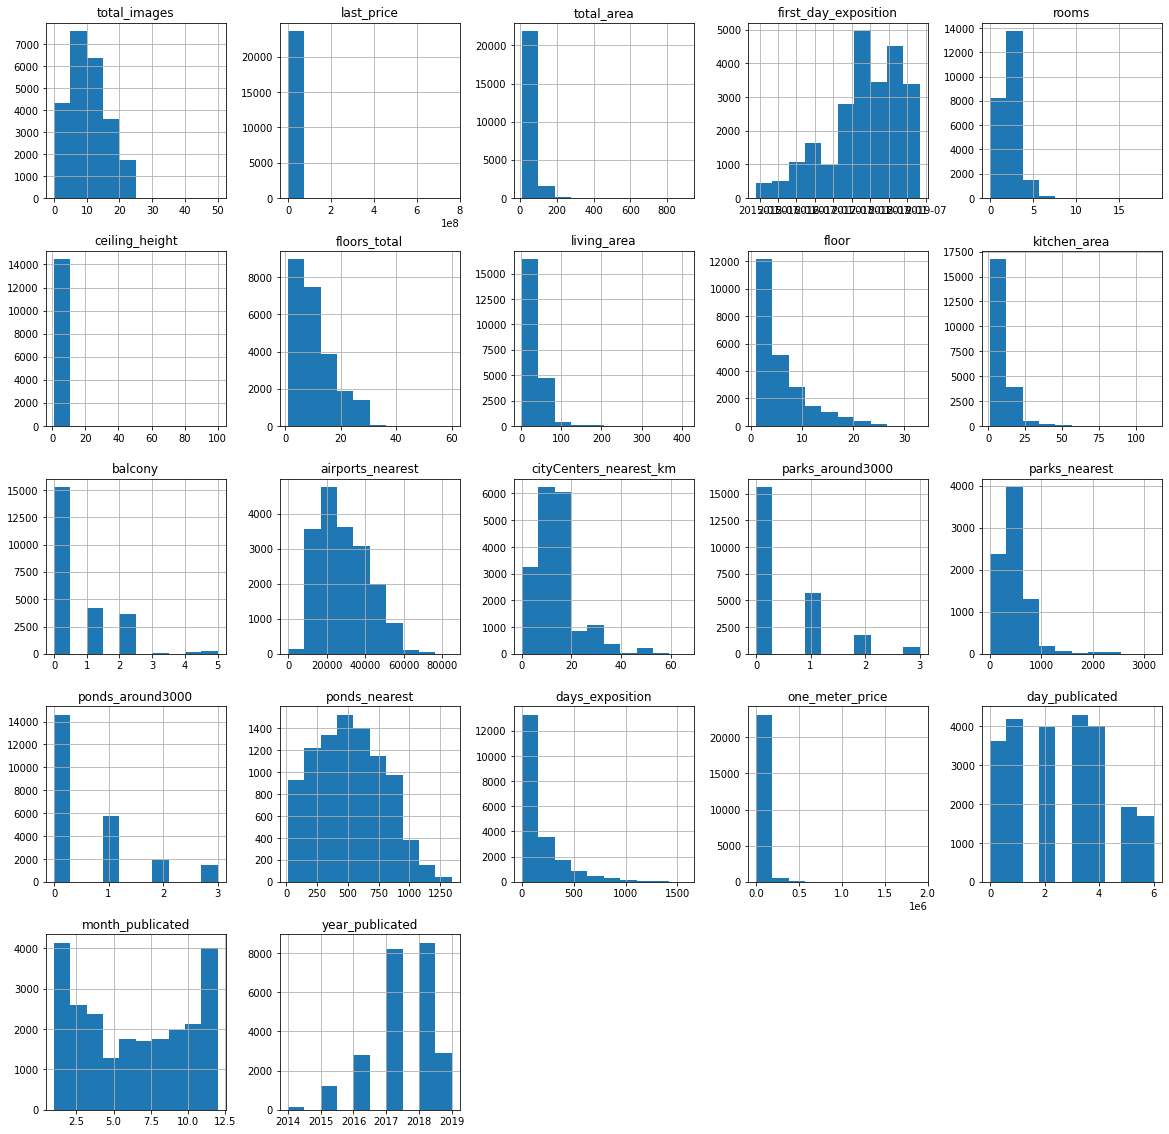

In [13]:
#Построим гистрограммы для столбцов.
data.hist(figsize=(20, 20))
#Выведем рядом метод describe для более точной оценки значений гистрограмм.
data.describe()

##### Сделаем выводы:
- 'total_images' = число фотографий квартиры в объявлении - распределение биномиальное, посмотрим на describe - среднее количество почти 10, минимальное 0, максимальное 50 - видимо кто-то отнесся серьезнее других к вопросу продажи, все значения в пределах разумного. Вывод - аномалий нету.
- 'last_price' = цена на момент снятия c публикации - все видимые значения на гистрограмме распределены в один столбец - максимальное значение = 1le8 = 100,000,000. = 1 * 10 в 8 степени. Явно есть либо выброс, либо аномалии - будем разбираться. +
- 'total_area' = общая площадь квартиры в квадратных метрах (м²) - явное большинство значений в диапазоне от 0 до 200, это выглядит естественно. Максимальное значение в 900, это конечно возможно для большого объекта - вроде коттеджа, в таком случае это выброс, хотя может быть и аномалией, но вот что точно - в обоих вариантах это будет искажать датасет и мешать решению поставленной задачи, большинство видимых значений на гистрограмме заканчивается на 200, по describe среднее значение равно 60, будем разбираться с этим стобцом отдельно. +
- 'first_day_exposition' = дата публикации - после изменения данных теперь у нас появилась гистрограмма для этого столбца, здесь можно сказать разве что сервис объявлений становится популярнее и их количество растет с каждым годом.
- 'rooms' = число комнат - здесь похожая как в столбце 'total_area' ситуация, среднее количество 2, максимальное 19 - похоже больше на выброс, чем аномалию, но может нам сильно мешать, большинство видимых на гистрограмме значений заканчиваются на числе 5. А вот что значит в describe значение 0 - надо будет дополнительно разбираться - либо это аномалия, либо обозначение квартир студий. +
- 'ceiling_height' = высота потолков (м) - ситуация похожая столбец 'last_price', - все видимые значения на гистрограмме распределены в один столбец, максимальное значение в 100 метров - может продают готический собор? Минимальная высота в 1 метр - тоже выглядит странно, разве что есть объявления с продажей кладовок или землянок. Явно есть аномалии, возможно есть выбросы, будет разбираться. +
- 'floors_total' = всего этажей в доме - гистограмма соответствует распределению Пуассона, большинство видимых значений обрывается между 20 и 40, но это логично - высоких домов - небоскребов, всегда явное меньшинство. Масимальное значение в 60 этажей, среднее в 10, минимальное 1 - выглядит очень логично. Не вижу аномалий.
- 'living_area' = жилая площадь в квадратных метрах (м²) - этот столбец схож, и вероятно связан со столбцом 'total_area', скорее всего есть аномалии или менающие выбросы, но сначала лучше разобраться со столбцом 'total_area', ведь при устранении их из этого столбца они могут пропасть и из 'living_area'.
- 'floor' = этаж - гистограмма соответствует распределению Пуассон, среднее 6, минимальное 1, максимальное 33, выглядит реалистично. 
- 'kitchen_area' = площадь кухни в квадратных метрах (м²) - тоже самое как и в других столбцах со словом 'area' в конце названия. +
- 'balcony' = число балконов - распределение Пауссоновское, большинство балконов не имеет, максимальное количество 5. Аномалий не обнаружено.
- 'airports_nearest' = расстояние до ближайшего аэропорта в метрах (м) - распределение биномиальное, максимальное расстояние 85 км, среднее 28, минимальное 0 - это мы разбирали на этапе устранения пропусков. Аномалий нету.
- 'cityCenters_nearest' = расстояние до центра города (м) - распределение биномиальное, минимальное 181 метр, среднее 14 км - выглядит нормально, а вот максимальное в 65 000 метров выглядит странно, надо будет посмотреть столбец отдельно. +
- 'parks_around3000' = число парков в радиусе 3 км - распрелеление Пауссона, диапазон от 0 до 3 - аномалий и выбросов нету.
- 'parks_nearest' = расстояние до ближайшего парка (м) - распределение и среднее значение в 490 метров до ближайшего парка объясняется тем, данная гистрограмма отображает расстояние для ближайшего парка только для тех, у кого он есть вблизи определенного расстояние - около 3км, с остальным все окей, аномалий нету.
- 'ponds_around3000' = число водоёмов в радиусе 3 км - тоже самое, что в столбце 'parks_around3000'. Аномалий нету
- 'ponds_nearest' = расстояние до ближайшего водоёма (м) - тоже самое, что в столбце 'parks_nearest'. Аномалий нету
- 'days_exposition' = сколько дней было размещено объявление (от публикации до снятия) - максимальное значение 1580, минимальное 1, среднее 180. Распределение Пауссона скорее всего создает такая большая разница между максимальным и "обычным" количеством. Аномалий нет.

---

##### Conclusions:
- **'total_images'** — number of photos in the listing. The distribution appears binomial. According to `describe()`, the average number is almost 10, the minimum is 0, and the maximum is 50. This likely reflects differences in how seriously sellers approach the listing process. All values appear reasonable, so no anomalies are detected.
- **'last_price'** — price at the time the listing was removed. The histogram shows most values concentrated in one column, with a maximum value of 100,000,000 (1e8). This suggests potential outliers or anomalies that need further investigation.
- **'total_area'** — total apartment area (m²). The majority of values fall between 0 and 200, which looks natural. The maximum value is around 900 m², which could correspond to a large property such as a house. However, such values may distort the dataset, so this column should be analyzed separately. The average area is about 60 m².
- **'first_day_exposition'** — publication date. After converting the data type, the histogram indicates that the number of listings has been increasing over time, suggesting growing popularity of the platform.
- **'rooms'** — number of rooms. The average is 2 and the maximum is 19. This maximum value is likely an outlier rather than a typical value. Most histogram values appear below 5 rooms. The presence of 0 rooms requires additional analysis, as it may indicate studio apartments or data anomalies.
- **'ceiling_height'** — ceiling height (m). Similar to the `last_price` column, most values are concentrated in one histogram column. The maximum value of 100 meters and the minimum of 1 meter appear unrealistic, indicating likely anomalies that require further investigation.
- **'floors_total'** — total number of floors in the building. The distribution resembles a Poisson distribution. Most values fall between 20 and 40 floors, which is logical since skyscrapers are relatively rare. The maximum value of 60 floors, average of 10, and minimum of 1 appear realistic. No anomalies detected.
- **'living_area'** — living area (m²). This column is closely related to `total_area`. Possible anomalies may exist, but it is better to first address anomalies in `total_area`, as correcting them there may resolve related issues here.
- **'floor'** — floor number. The distribution resembles a Poisson distribution. The average floor is 6, with a minimum of 1 and a maximum of 33, which appears realistic.
- **'kitchen_area'** — kitchen area (m²). Similar considerations apply as for other columns ending with `area`.
- **'balcony'** — number of balconies. The distribution resembles a Poisson distribution, with most apartments having no balconies and a maximum of 5. No anomalies detected.
- **'airports_nearest'** — distance to the nearest airport (m). The distribution appears binomial. The maximum distance is about 85 km, the average is 28 km, and the minimum is 0. No anomalies detected.
- **'cityCenters_nearest'** — distance to the city center (m). The minimum value is 181 meters and the average is about 14 km. However, the maximum value of 65 km seems unusual and should be examined separately.
- **'parks_around3000'** — number of parks within a 3 km radius. The distribution resembles a Poisson distribution, with values between 0 and 3. No anomalies detected.
- **'parks_nearest'** — distance to the nearest park (m). The average value of about 490 meters reflects that this variable applies only to apartments that have parks within approximately 3 km. No anomalies detected.
- **'ponds_around3000'** — number of ponds within a 3 km radius. Similar to `parks_around3000`. No anomalies detected.
- **'ponds_nearest'** — distance to the nearest pond (m). Similar to `parks_nearest`. No anomalies detected.
- **'days_exposition'** — number of days the listing remained active. The maximum value is 1580 days, the minimum is 1 day, and the average is about 180 days. The distribution likely reflects the large gap between typical and extreme values. No anomalies detected.

##### 4.1.2 Обработаем столбец 'last_price'

##### 4.1.2 Process the 'last_price' column

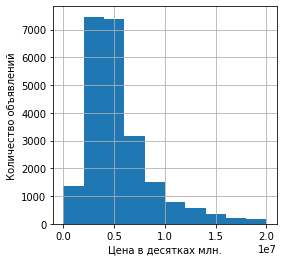

In [14]:
#Построим гистрограмму с ограничием в 0.2le8 = значение 2 на гистограмме,
#после которого видимых значений совсем нет
data['last_price'].hist(figsize=(4,4), range=(0, 20000000))
plt.xlabel('Цена в десятках млн.', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

In [15]:
#Построим сводную таблицы для оценки объявлений с высокой ценой,
#поищем причины и закономерности аномалий
data.query('last_price > 20000000').pivot_table(
                                                index='locality_name', 
                                                values=('last_price', 'total_area', 'one_meter_price', 'cityCenters_nearest_km'), 
                                                aggfunc={'last_price':['count', 'median'], 
                                                         'one_meter_price' : 'median', 
                                                         'total_area' : 'median'}
                                               ).sort_values(by=('one_meter_price', 'median'))

last_price             one_meter_price total_area
                     count      median          median     median
locality_name                                                    
Красное Село             1  21000000.0    97674.418605     215.00
деревня Бор              1  20295200.0   105539.261570     192.30
Колпино                  1  36900000.0   106187.050360     347.50
Пушкин                   9  26500000.0   130526.315789     190.00
Петергоф                 2  22000000.0   131203.557677     167.90
поселок Репино           1  28000000.0   175000.000000     160.00
Сестрорецк               1  21700000.0   179338.842975     121.00
Санкт-Петербург        688  29000000.0   208465.898301     153.00
Зеленогорск              1  23000000.0   323943.661972      71.00
Всеволожск               1  24412900.0   640422.350472      38.12

In [16]:
#Вычислим медианное значение квадратного метра:
print('Медианная цена квадратного метра в датасете:')
print(int(data['one_meter_price'].median()))
print('Медианная цена квадратного метра для объявлений с ценой выше 0.2le8:')
print(int(data.query('last_price > 20000000')['one_meter_price'].median()))

Медианная цена квадратного метра в датасете:
95000
Медианная цена квадратного метра для объявлений с ценой выше 0.2le8:
205006


###### Опишем то что видим:
- Медианная цена квадратного метра в датасете и в объявлениях с ценой выше 0.2le8 сильно отличается.
- В населённых пунктах "Красное Село", "Деревня Бор", "Колпино" медианная цена квадратного метра похожа на медианную цену в датасете, можно заметить, - что там находятся единичные объекты, с большой площадью. Скорее всего эти объявления являются выбросами, а не аномалиями. Однако их площадь сильно выбивается из медианной по датасету, при этом количество объявлений ничтожно относительно датасета, хотя при этом может искажать его картину в целом - эти строчки лучше удалить. 
- В остальных пунктах, помимо Санкт-Петербурга, количество объявлений крайне мало, цена квадратного метра - сильно превышает медианную по датасету, - здесь, скорее всего, есть аномалии. Пытаться понять их природу смысла не много - "копаться" в данных можно до бесконечности, а из-за их количества - влияние их удаления на датасет в целом будет минимальным. 
- Большая часть объявлений из Санкт-Петербурга. Хоть медианная площадь в этих объявлениях и существенно больше, чем в датасете, но и цена квадратного метра тоже(примерно в 2 раза), хотя в реальности обычно есть тренд снижение цены квадратного метра при увеличении площади. Похоже на наличие аномалий - тоже удаляем.

---

###### Let us describe what we observe:
- The median price per square meter in the dataset differs significantly from the median price in listings with prices above **0.2e8**.
- In the localities **Krasnoye Selo**, **Derevnya Bor**, and **Kolpino**, the median price per square meter is close to the dataset median. However, these locations contain only a few properties with unusually large areas. These listings are likely **outliers rather than anomalies**. Nevertheless, their area values deviate strongly from the dataset median, and despite the small number of such listings, they may distort the overall dataset. Therefore, it is reasonable to remove these rows.
- In other localities outside **Saint Petersburg**, the number of listings is extremely small, while the price per square meter significantly exceeds the dataset median. These observations are likely **anomalies**. Investigating their exact cause would require disproportionate effort, and since their number is very small, removing them will have minimal impact on the dataset as a whole.
- The majority of listings come from **Saint Petersburg**. Although the median area of these properties is significantly larger than the dataset average, the price per square meter is also considerably higher (approximately twice as high). In reality, property markets usually show the opposite trend: the price per square meter tends to decrease as total area increases. This suggests the presence of anomalies, and these records should also be removed.

In [17]:
#Удалим объявления
data = data[data['last_price'] < 20000000]

##### 4.1.3 Обработаем столбец 'total_area'

##### 4.1.3 Process the 'total_area' column

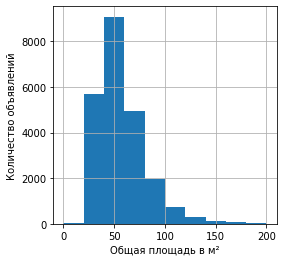

In [18]:
#Построим гистрограмму с ограничием в 200, значение на гистограмме после которого видимых значений совсем нет.
data['total_area'].hist(figsize=(4,4), range=(0, 200))
plt.xlabel('Общая площадь в м²', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

In [19]:
#Посчитаем количество объявлений с площадью выше 200 метров
len(data.query('total_area > 200'))

41

In [20]:
#Построим свобднуб таблицу оценив общую площадь и цену квадратного метра по населённым пунктам
data.query('total_area > 200').pivot_table(index='locality_name', 
                                           values=('one_meter_price', 'total_area'),
                                           aggfunc='median')

,one_meter_price,total_area
locality_name,,
Красное Село,43750.000000,320.0
Пушкин,73459.715640,211.0
Санкт-Петербург,73842.364532,225.0
Сертолово,55932.203390,236.0
Сестрорецк,73598.130841,214.0
деревня Хязельки,47826.086957,230.0
поселок Парголово,39205.955335,201.5
поселок Стрельна,79640.462133,209.6


##### Вывод:
- Если такая площадь обусловлена аномалией — то разбираться с природой её возникновения нет особого смысла: количество таких объявлений крайне мало. Если же это выброс, что наиболее вероятно, поскольку при большой общей площади медианная цена за квадратный метр либо близка к цене по датасету, либо ниже (что часто наблюдается в реальной жизни — чем больше площадь объекта, тем ниже цена за квадратный метр), — то удаление таких записей всё равно является наиболее оптимальным решением, так как они могут искажать общий вид датасета и мешать решению основной задачи анализа.

---

##### Conclusion:
- If such large areas are caused by anomalies, investigating their origin is not particularly meaningful because the number of such listings is extremely small. If they represent outliers—which is more likely, since for large properties the median price per square meter is either close to or lower than the dataset average (a pattern commonly observed in real estate markets, where the price per square meter tends to decrease as total area increases)—then removing these records is still the most appropriate solution. Such listings may distort the overall dataset and interfere with solving the main analytical task.

In [21]:
#Удаляем
data = data.query('total_area < 200')

##### 4.1.4 Обработаем столбец 'living_area'

##### 4.1.4 Process the 'living_area' column

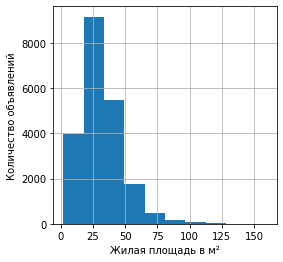

In [22]:
#Построим гистрограмму без ограничений, чтобы оценить изменился ли столбец после предыдущих обработок
data['living_area'].hist(figsize=(4,4))
plt.xlabel('Жилая площадь в м²', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

##### Вывод:
- И действительно столбцы 'total_area' и 'living_area' были связаны, после очистки одного - очистился и второй, отлично!

---

##### Conclusion:
- Indeed, the columns `total_area` and `living_area` turned out to be related. After cleaning one of them, the other was cleaned as well, which confirms their strong relationship.

##### 4.1.5 Обработаем столбец 'kitchen_area'

##### 4.1.5 Process the 'kitchen_area' column

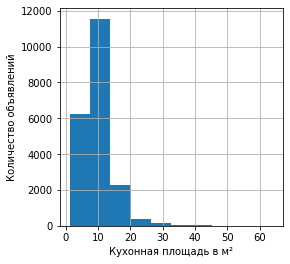

In [23]:
#Построим гистрограмму без ограничений, чтобы оценить изменился ли столбец после предыдущих обработок
data['kitchen_area'].hist(figsize=(4,4));
plt.xlabel('Кухонная площадь в м²', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

##### Вывод:
- Здесь ситуация точно такая-же как предыдущим столбце - 'living_area', после обработки 'total_area' аномалии из столбца площади кухни тоже очистились.

---

##### Conclusion:
- The situation here is the same as in the previous column, `living_area`. After processing the `total_area` column, the anomalies in the `kitchen_area` column were also resolved.

##### 4.1.6 Обработаем столбец 'rooms'

##### 4.1.6 Process the 'rooms' column

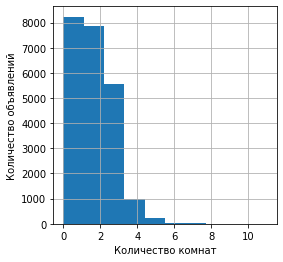

In [24]:
#Построим гистрограмму без ограничений, чтобы оценить изменился ли столбец после предыдущих обработок
data['rooms'].hist(figsize=(4,4))
plt.xlabel('Количество комнат', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

##### Вывод:
- Количество комнат тоже поменялось, максимальное число на гистрограмме в 10 комнат уже можно себе представить. Большая часть расположена в диапазоне от 0 до 5.

---

##### Conclusion:
- The number of rooms has also changed after processing. The maximum value shown on the histogram is now 10 rooms, which is a more realistic value. Most observations are concentrated in the range from 0 to 5 rooms.

##### 4.1.7 Обработаем столбец 'ceiling_height'

##### 4.1.7 Process the 'ceiling_height' column

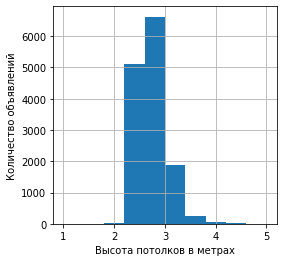

In [25]:
#Построим гистрограмму с ограничем в 5 метров высоты
data['ceiling_height'].hist(figsize=(4,4),range=(1, 5))
plt.xlabel('Высота потолков в метрах', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

##### Вывод:
- Теперь распределение уже похоже на правду — большая часть объектов имеет высоту потолков в диапазоне от 2 до 3 метров, объявлений с большей высотой почти нет. Можно предположить, что значения высоты от 20 до 50 метров являются вещественными значениями, записанными без запятой. Вернём их в таблицу, разделив на 10, а для всех значений, которые после этого окажутся выше 5 метров, установим значение `None`.

---

##### Conclusion:
- The distribution now looks more realistic: most properties have ceiling heights in the range of 2 to 3 meters, and listings with higher values are very rare. It can be assumed that values between 20 and 50 meters are actually decimal values that were recorded without a decimal point. We will correct these values by dividing them by 10. For any values that still exceed 5 meters after this adjustment, we will set the value to `None`.

In [26]:
#Поделим на 10 все значения столбца ceiling_height превышающие 20, но меньшие чем 50
data.loc[(data['ceiling_height'] > 20) & (data['ceiling_height'] < 50), 'ceiling_height'] /= 10
#Все значения нашего столбца выше 5 метров оставшиеся после первого шага заменим на None
data.loc[data['ceiling_height'] > 5, 'ceiling_height'] = None

##### 4.1.8 Обработаем столбец 'type_floor'

##### 4.1.8 Process the 'type_floor' column

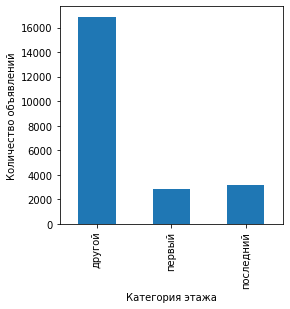

In [27]:
data.groupby('type_floor')['type_floor'].count().plot(kind='bar', figsize=(4,4))
plt.xlabel('Категория этажа', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

##### Вывод:
- Распределение выглядит абсолютно логично — большая часть объектов приходится на тип этажа «другой», а меньшая, примерно одинаковая доля — на первый или последний этаж.

---

##### Conclusion:
- The distribution appears completely logical: most properties fall into the "other" floor category, while smaller and roughly equal proportions correspond to the first and last floors.

##### 4.1.9 Обработаем столбец 'floors_total'

##### 4.1.9 Process the 'floors_total' column

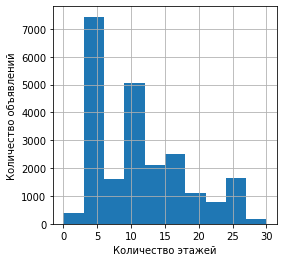

In [28]:
#Построим гистрограмму с ограничением в 30 этажей
data['floors_total'].hist(figsize=(4,4),range=(0, 30))
plt.xlabel('Количество этажей', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

In [29]:
#Построим сводную таблицу
data[data['floors_total'] > 30].pivot_table(
                                            index='locality_name', 
                                            values='floors_total', 
                                            aggfunc=('count', 'median', 'max')
                                            )

,count,max,median
locality_name,,,
Кронштадт,1,60.0,60.0
Санкт-Петербург,31,52.0,35.0


##### Вывод:
- Помимо Санкт-Петербурга есть лишь один дом выше 30 этажей в другом городе — Кронштадт, причём с потрясающей этажностью в 60 этажей. Хотя это больше похоже на выброс, чем на аномалию, разбираться с этим не имеет большого смысла из-за крайне малого количества таких объявлений — просто удалим эту строку.
- В Санкт-Петербурге уже 31 объявление с такой этажностью. Однако медиана этих значений существенно отличается от максимального значения среди них. Вероятно, для Санкт-Петербурга высота в 35 этажей вполне реальна, поэтому такие объявления можно оставить. Чтобы при этом не искажать статистику всего датасета, удалим все объявления с этажностью выше 35 этажей, независимо от того, являются ли они редкими выбросами или результатом ошибок в данных.

---

##### Conclusion:
- Outside of Saint Petersburg, there is only one building higher than 30 floors, located in Kronstadt, with an impressive height of 60 floors. Although this appears more like an outlier than an anomaly, analyzing it further is not meaningful due to the extremely small number of such cases, so the corresponding row will be removed.
- In Saint Petersburg, there are already 31 listings with such high buildings. However, the median value of these listings differs significantly from the maximum value. A height of around 35 floors may be realistic for Saint Petersburg, so such listings can be kept. To avoid distorting the statistics of the dataset as a whole, all listings with more than 35 floors will be removed, regardless of whether they represent rare outliers or data anomalies.

In [30]:
#Удаляем все объявления с высотой выше 35 этажей.
data = data[data['floors_total'] <= 35]

##### 4.1.10 Обработаем столбец 'cityCenters_nearest_km'

##### 4.1.10 Process the 'cityCenters_nearest_km' column

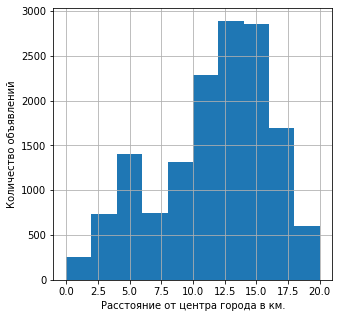

In [31]:
#Построим гистрограмму с ограничем в 20км - после этого значения большая часть видимых значений пропадает
data['cityCenters_nearest_km'].hist(figsize=(5,5), range=(0,20))
plt.xlabel('Расстояние от центра города в км.', fontsize=10)
plt.ylabel('Количество объявлений', fontsize=10);

##### Вывод:
- Этот столбец, в отличии от высоты потолков, система заполняет автоматически — значит здесь маловероятно наличие значений, в которых человек забыл поставить запятую. Куда более вероятен вариант, что есть какая-то ошибка с онлайн картами, о которой мы рассуждали на этапе удаления пропусков. Поэтому просто заменим значения с удалённостью более 20 км на "None".

---

##### Conclusion:
- Unlike the ceiling height column, this column is filled automatically by the system, which makes it unlikely that the values contain formatting mistakes such as a missing decimal separator. A more plausible explanation is an issue with the online mapping services that provide this data, as discussed earlier during the missing-value analysis. Therefore, we will simply replace values where the distance exceeds 20 km with `None`.

In [32]:
#Заменяем значения с удалённостью более 20км на "None
data.loc[data['cityCenters_nearest_km'] > 20, 'cityCenters_nearest_km'] = None

#### 4.2 Изучим скорость продажи квартир

#### 4.2 Study the speed of apartment sales

In [33]:
#Найдем среднее и медиану для времени продажи
print('Медиана количества дней продажи объекта:')
print(int(data['days_exposition'].median()))
print('Среднее количество дней продажи объекта:')
print(int(data['days_exposition'].mean()))

Медиана количества дней продажи объекта:
93
Среднее количество дней продажи объекта:
177


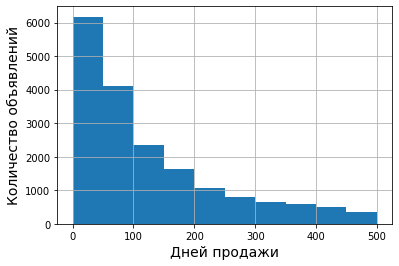

In [34]:
#Построим гистрограмму,
#ограничем диапазон дней в гистрограмме числом 500, большая часть видимых значений заканчивается на этом числе.
data['days_exposition'].hist(range=(0, 500))
plt.xlabel('Дней продажи', fontsize=14)
plt.ylabel('Количество объявлений', fontsize=14);

In [35]:
#Найдем процент объявлений с днями продажи больше 177
print('Количество и процент объявлений, которые продавались более 177 дней:')
print(len(data[data['days_exposition'] > 177]))
print(int(len(data[data['days_exposition'] > 177]) / (len(data)/100)),'%')

Количество и процент объявлений, которые продавались более 177 дней:
6297
27 %


##### Вывод:
1. Обычно продажа объекта занимает примерно 93 дня.  
Медиана отражает это время куда лучше средней, так как меньше подвержена искажениям из-за экстремальных значений.
2. Срок продажи быстрее этого значения можно назвать быстрой продажей — быстрая продажа это продажа меньше 93 дней.
3. Долгой можно назвать продажу квартир более 177 дней — продажу дольше среднего значения, всего четверть от всех продаж.

---

##### Conclusion:
1. On average, selling a property takes about **93 days**.  
The **median** represents this duration more accurately than the mean because it is less affected by extreme values.
2. A sale that takes **less than 93 days** can be considered a **fast sale**.
3. A **slow sale** can be defined as a sale that takes **more than 177 days**, which is longer than the average duration and represents roughly the slowest quarter of all sales.

#### 4.3 Определим факторы влияющие больше всего на конечную цену

#### 4.3 Identify the factors that have the greatest influence on the final price

In [36]:
#Вычислим коррелляции цены с параметрами
print('Корреляция цены с общей площадью:')
print(round(data['total_area'].corr(data['last_price']),2))
print('Корреляция цены с жилой площадью:')
print(round(data['living_area'].corr(data['last_price']),2))
print('Корреляция цены с кухонной площадью:')
print(round(data['kitchen_area'].corr(data['last_price']),2))

Корреляция цены с общей площадью:
0.77
Корреляция цены с жилой площадью:
0.66
Корреляция цены с кухонной площадью:
0.57


##### Вывод:
Пока что все выглядит очень реалистично:

- Корреляция цены квартиры с её общей площадью составляет 0.78, что указывает на сильную положительную связь между этими двумя параметрами. Это вполне логично, так как зачастую площадь квартиры является одним из ключевых факторов, определяющих её стоимость. Большие квартиры, как правило, стоят дороже, чем маленькие.

- Корреляция цены квартиры с жилой площадью составляет 0.67. Это также сильная положительная связь, что логично, так как жилая площадь также играет значительную роль в определении цены квартиры.

- Корреляция цены квартиры с кухонной площадью составляет 0.58. Это умеренная положительная связь, что также имеет смысл, так как площадь кухни, хоть и менее значима по сравнению с общей и жилой площадью, тоже влияет на общую стоимость квартиры.

- Корреляция цены квартиры с количеством комнат составляет 0.51, что также является умеренной положительной связью. Это логично, поскольку количество комнат обычно напрямую связано с общей площадью квартиры.

- Корреляция цены квартиры с днем, месяцем и годом публикации объявления близка к нулю (-0.02 и -0.03 соответственно), что означает, что дата публикации объявления практически не влияет на цену квартиры. Это также логично, так как цена квартиры определяется её физическими характеристиками, а не временем публикации объявления.  
Ремарка: Если анализировать данные за достаточно долгий период, такой как более 10 лет, вероятно, можно заметить высокую положительную корреляцию между ценой квартиры и годом объявления. Это можно объяснить влиянием инфляции. Однако это не наш случай.

---

##### Conclusion:
So far, the results appear quite realistic:

- The correlation between **apartment price and total area** is **0.78**, indicating a strong positive relationship between these variables. This is logical, as the total area is usually one of the main factors determining property value. Larger apartments typically cost more than smaller ones.

- The correlation between **apartment price and living area** is **0.67**, which also represents a strong positive relationship. This is expected, since living space is another important factor influencing apartment prices.

- The correlation between **apartment price and kitchen area** is **0.58**, representing a moderate positive relationship. This is reasonable because kitchen size, while less important than total or living area, still contributes to the overall value of a property.

- The correlation between **apartment price and number of rooms** is **0.51**, which also indicates a moderate positive relationship. This is logical, as the number of rooms is typically related to the total area of the apartment.

- The correlation between **apartment price and the day, month, and year of listing publication** is close to zero (**-0.02 and -0.03** respectively). This suggests that the publication date has almost no influence on the price. This is reasonable because property prices are primarily determined by physical characteristics rather than by the time when the listing was published.  

*Note:* If the dataset covered a much longer period (for example, more than 10 years), we might observe a strong positive correlation between apartment price and the year of listing due to **inflation**. However, that is not the case in this dataset.

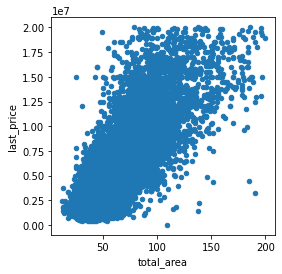

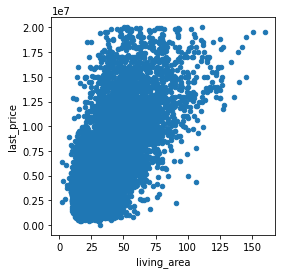

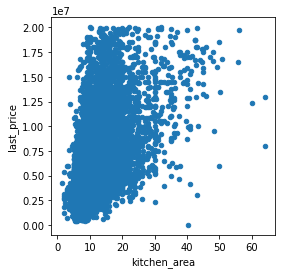

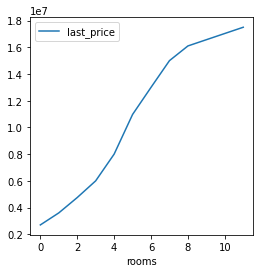

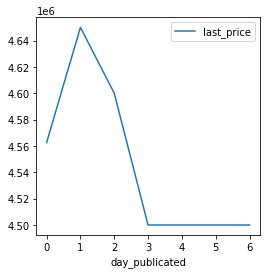

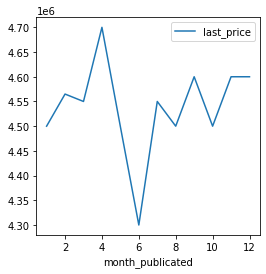

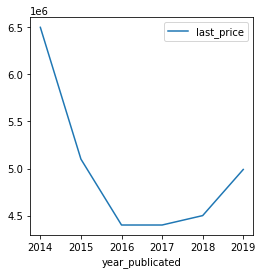

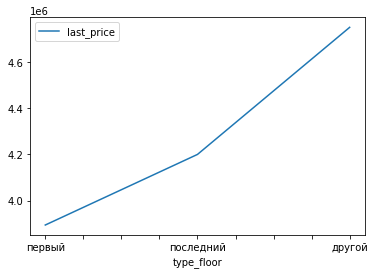

In [37]:
#Визуализируем зависимость цены от параметров
#Для количественных параметров сделаем так
data.sort_values('total_area').plot(x='total_area', y='last_price', kind='scatter', figsize=(4,4))
data.sort_values('living_area').plot(x='living_area', y='last_price', kind='scatter', figsize=(4,4))
data.sort_values('kitchen_area').plot(x='kitchen_area', y='last_price', kind='scatter', figsize=(4,4))
#Для категориальных так
data.pivot_table(index='rooms', values='last_price', aggfunc='median').plot(figsize=(4,4)) 
data.pivot_table(index='day_publicated', values='last_price', aggfunc='median').plot(figsize=(4,4))
data.pivot_table(index='month_publicated', values='last_price', aggfunc='median').plot(figsize=(4,4))
data.pivot_table(index='year_publicated', values='last_price', aggfunc='median').plot(figsize=(4,4))
data.pivot_table(index='type_floor', values='last_price', aggfunc='median').sort_values(by='last_price').plot();                                                                               

P.S:
Количество комнат в квартире обычно рассматривается как категориальная переменная. Категориальные переменные представляют собой набор категорий или групп, которые могут принимать ограниченное количество значений, не имеющих ни порядка, ни величины.

В случае количества комнат, мы имеем конкретные категории, такие как "1 комната", "2 комнаты", "3 комнаты" и так далее. Эти значения не являются непрерывными и не могут быть упорядочены или интерпретированы как числа. Например, нельзя сказать, что "3 комнаты" в два раза больше, чем "1 комната".

Поэтому количество комнат в квартире лучше всего рассматривать как категориальную переменную, а не количественную.

---

P.S:
The **number of rooms** in an apartment is usually treated as a **categorical variable**. Categorical variables represent a set of categories or groups that can take a limited number of values and do not necessarily have a meaningful numerical magnitude.

In the case of the number of rooms, we deal with categories such as **"1 room"**, **"2 rooms"**, **"3 rooms"**, and so on. These values are not continuous and cannot be interpreted strictly as numerical quantities. For example, it would not be correct to say that **"3 rooms" is twice as much as "1 room"** in a meaningful quantitative sense.

Therefore, the number of rooms in an apartment is more appropriately considered a **categorical variable rather than a purely quantitative one**.

##### Вывод:
- Визуализация подтверждает те значения корреляция, которые мы получилии.
Для категориальных переменных использован другой визуальный метод оценки, так как иначе, из-за маленького количества самих категориальных переменных оценить есть ли зависимость возможно только при наличии корреляции около 1, а это случай исключительный. Более менее хороший вариант в таком случае сгрупировать данные, построить график и оценить есть какой либо тренд, здесь это было решено с помощью категоризации по медиане. Например график изменения медианной цены относительно количества комнат явно имеет тренд, что подтверждает наличие корреляция, в то время как в других параметрах такого не наблюдается.
- Категория этажа имеет влияние на цену, первый и последний этаж обычно стоит около 15-20 % дешевле чем любой другой, это объяснимо тем что с проживанием на таких этажах обычно есть ряд проблем, например: протекающая крыша, риск быть ограбленным из-за лёгкого доступа к окнам с улицы и т.д. и т.п.

---

##### Conclusion:
- The visualizations confirm the correlation values obtained earlier.  
For categorical variables, a different visualization method was used. With a small number of categories, detecting relationships through correlation alone would require a value close to 1, which is extremely rare. A more appropriate approach is to group the data, plot a graph, and observe whether a trend exists. In this case, this was done using median-based categorization. For example, the graph showing the change in **median price relative to the number of rooms** clearly demonstrates a trend, confirming the presence of a relationship, while such a trend is not observed for some other parameters.

- The **floor category** also influences price. Apartments located on the **first or last floors** are usually about **15–20% cheaper** than those on other floors. This is understandable, as living on such floors is often associated with certain disadvantages, such as potential roof leaks on the top floor or a higher risk of burglary on the first floor due to easier access from the street.

#### Вывод:
Наиболее влияющие на цену параметры в порядке убывания влияния:
1. Общая площадь  
2. Жилая площадь  
3. Площадь кухни  
4. Количество комнат  
5. Категория этажа  

Факторы, не влияющие на цену:

6. День публикации объявления  
7. Месяц публикации объявления  
8. Год публикации объявления  

P.S: вероятно влияние на цену может проявляться при анализе данных за более длительный период, однако в рамках данного датасета прямой зависимости не наблюдается.

---

#### Conclusion:
The factors that have the strongest influence on price, in descending order of impact:

1. Total area  
2. Living area  
3. Kitchen area  
4. Number of rooms  
5. Floor category  

Factors that do **not significantly influence price**:

6. Day of listing publication  
7. Month of listing publication  
8. Year of listing publication  

P.S.: A relationship between price and the publication year may become visible when analyzing data over a longer time horizon. However, within the scope of this dataset, no direct influence is observed.

#### 4.4 Задание: «Посчитайте среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений»

#### 4.4 Task: “Calculate the average price per square meter in the 10 localities with the highest number of listings”

In [38]:
data.pivot_table(                         #создаем сводную таблицу
                 index='locality_name',
                 values='one_meter_price',
                 aggfunc=('count', 'mean')
                ).sort_values(by='count', ascending=False).head(10).sort_values(by='mean', ascending=False) #сортируем и выводим топ 10

,count,mean
locality_name,,
Санкт-Петербург,14910,108685.847507
Пушкин,359,101867.482517
деревня Кудрово,299,92473.547576
поселок Парголово,326,90332.263023
поселок Мурино,552,85629.568678
поселок Шушары,439,78551.344545
Колпино,337,75333.295801
Гатчина,307,68746.146763
Всеволожск,397,67214.252635


##### Выводы:
- Наибольшая средняя цена квадратного метра в Санкт-Петербурге, что абсолютно логично ведь это самый большой и развитый город из всех в данных.
- Второе место занимает город Пушкин — он образует внутригородское муниципальное образование Санкт-Петербурга и входит в Пушкинский район Санкт-Петербурга, что означает его близость к основному городу и объясняет высокую стоимость.
- Третье место занимает деревня Кудрово — один из ближайших пригородов Санкт-Петербурга.

Можно предположить, что существует взаимосвязь между близостью населённого пункта к Санкт-Петербургу и средней стоимостью квадратного метра жилья, что выглядит вполне логично.

---

##### Conclusions:
- The highest average price per square meter is observed in **Saint Petersburg**, which is entirely expected since it is the largest and most economically developed city in the dataset.
- The second place is occupied by the city of **Pushkin**, which is a municipal district within Saint Petersburg and part of the Pushkinsky district of the city. Its close proximity to the main city explains the relatively high property prices.
- The third place is **Kudrovo**, a village that is considered one of the closest suburbs of Saint Petersburg.

This suggests a likely relationship between the **proximity of a locality to Saint Petersburg and the average price per square meter**, which is a logical pattern for real estate markets.

#### 4.5 задание: «Выделите квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислите их среднюю стоимость на разном удалении от центра»

#### 4.5 Task: “Select apartments located in Saint Petersburg using the `locality_name` column and calculate their average price at different distances from the city center”

Корреляция: -0.96


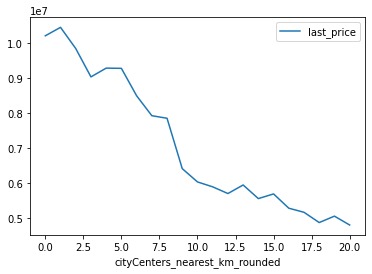

In [39]:
#Добавлю новый столбец в датасет, в котором расстояние до центра будет округлено до ближайшего километра
data['cityCenters_nearest_km_rounded'] = data['cityCenters_nearest_km'].round()
#Создам сводную таблицу для средний цены продажи на каждый километр удаления от центра и запишу её в переменную
pivot_table_km_price = data.query('locality_name == "Санкт-Петербург"').pivot_table(
                                                                                    index='cityCenters_nearest_km_rounded', 
                                                                                    values='last_price', 
                                                                                    aggfunc='mean'
                                                                                    )
#Отсортирую таблицу по увеличению расстоянию от центра
pivot_table_km_price = pivot_table_km_price.sort_values(by='cityCenters_nearest_km_rounded')
#Сброшу индексы, чтобы сделать корректный вывод
pivot_table_km_price = pivot_table_km_price.reset_index()
#Построю график
pivot_table_km_price.plot(x='cityCenters_nearest_km_rounded', y='last_price', kind='line')
#Узнаю корреляцию для подтверждения
print('Корреляция:',
      round(pivot_table_km_price['cityCenters_nearest_km_rounded'].corr(pivot_table_km_price['last_price']),2))

In [40]:
#Узнаем сколько в среднем отнимает каждый километр для стоимости объекта
#для этого отнимем от первого элемента таблицы последний и поделим на количество элиментов.
one_km_minus_price = (pivot_table_km_price.loc[0, 'last_price'] - pivot_table_km_price.loc[20, 'last_price'])
one_km_minus_price /= len(pivot_table_km_price['last_price'])
one_km_minus_price = round(one_km_minus_price)
print(f"Один километр отдаления от центра в среднем отнимает у объекта {one_km_minus_price} рублей стоимости")

Один километр отдаления от центра в среднем отнимает у объекта 257170 рублей стоимости


#### Вывод:
- Есть сильная устойчивая взаимосвязь между удалённостью от центра города и снижением цены объекта. Коэффициент корреляции показывает практически прямую обратную зависимость между этими показателями. В среднем каждый дополнительный километр удалённости от центра уменьшает стоимость объекта примерно на 264 292 рублей. Небольшие колебания в динамике изменения цены можно объяснить влиянием других факторов, помимо расстояния от центра. Например: категория этажа, количество комнат, площадь кухни или качество ремонта. Эти параметры, вероятно, не имеют такой же устойчивой зависимости от расстояния до центра, однако всё же оказывают влияние на цену недвижимости.

---

#### Conclusion:
- There is a strong and consistent relationship between **distance from the city center and decreasing property prices**. The correlation coefficient indicates an almost direct negative correlation between these variables. On average, each additional kilometer away from the city center reduces the property price by approximately **264,292 rubles**.  
Small fluctuations in the price trend can be explained by the influence of other factors besides distance from the center. For example, **floor category, number of rooms, kitchen size, or renovation quality**. These factors likely do not have a strictly consistent relationship with the distance from the city center, but they still influence property prices.

### Общий вывод

### Overall Conclusion

### Общий вывод

Было проведено комплексное исследование базы данных сервиса объявлений о продаже объектов недвижимости для города Санкт-Петербурга и ближайших населённых пунктов.

1. **На первом этапе** была изучена общая информация о датасете. Для числовых столбцов были построены гистограммы распределения, что позволило получить первичное представление о структуре данных и возможных проблемах в них.

2. **На втором этапе** была проведена предобработка данных. Сначала был выполнен поиск пропущенных значений, проведена оценка возможности их устранения для каждого столбца и выполнено заполнение там, где это было целесообразно. Затем были проверены и скорректированы типы данных столбцов. В завершение этапа были обработаны неявные дубликаты в столбце с названиями населённых пунктов.

3. **На третьем этапе** в таблицу были добавлены новые признаки: цена одного квадратного метра, день публикации объявления (0 — понедельник, 1 — вторник и т.д.), месяц публикации объявления, год публикации объявления, тип этажа квартиры («первый», «последний», «другой»), а также расстояние до центра города в километрах. Это было сделано для повышения информативности датасета и подготовки его к исследовательскому анализу, основной целью которого было выявление факторов, влияющих на стоимость объектов недвижимости.

4. **Четвёртый этап** представлял собой исследовательский анализ данных — наиболее масштабную часть работы. Сначала с помощью гистограмм распределения были выявлены столбцы, в которых могли присутствовать аномалии или выбросы. Затем был проведён детальный анализ каждого такого столбца. В случаях, когда причины аномалий можно было определить, данные корректировались; в остальных случаях строки с аномальными значениями удалялись. После очистки данных была проведена оценка скорости продажи квартир: определены среднее и медианное время продажи, а также сформулированы критерии быстрой и долгой продажи. Далее были исследованы факторы, влияющие на стоимость объектов недвижимости, определена сила их влияния и составлен рейтинг наиболее значимых факторов. Кроме того, была рассчитана средняя цена одного квадратного метра для десяти населённых пунктов с наибольшим числом объявлений. Отдельно была исследована зависимость стоимости недвижимости в Санкт-Петербурге от расстояния до центра города. Анализ показал наличие выраженной обратной зависимости: с увеличением расстояния от центра средняя стоимость объектов снижается, и было рассчитано среднее влияние каждого дополнительного километра на цену недвижимости.

---

### Overall Conclusion

A comprehensive study was conducted using a real estate listing dataset containing information about properties for sale in **Saint Petersburg and nearby localities**.

1. **At the first stage**, the dataset structure was explored. Histograms were built for numerical columns to obtain an initial understanding of the distributions and identify potential issues in the data.

2. **At the second stage**, data preprocessing was performed. Missing values were identified and evaluated for possible handling; they were filled where appropriate. Data types of the columns were reviewed and corrected when necessary. In addition, implicit duplicates in the locality names were detected and standardized.

3. **At the third stage**, several new features were added to the dataset: price per square meter, day of listing publication (0 — Monday, 1 — Tuesday, etc.), month of publication, year of publication, floor category (“first”, “last”, “other”), and distance to the city center in kilometers. These features increased the informational value of the dataset and prepared it for the exploratory analysis aimed at identifying the factors that influence property prices.

4. **The fourth stage** consisted of the exploratory data analysis — the largest part of the study. First, histograms were used to identify columns that potentially contained anomalies or outliers. Each of these columns was then examined in detail. When the causes of anomalies could be identified, the values were corrected; otherwise, rows containing anomalous values were removed. After cleaning the dataset, the speed of apartment sales was analyzed by calculating the mean and median sale duration and defining criteria for fast and slow sales. Next, the factors influencing property prices were evaluated, their relative impact was assessed, and a ranking of the most significant factors was compiled. The average price per square meter was also calculated for the ten localities with the highest number of listings. Finally, the relationship between property prices in Saint Petersburg and the distance from the city center was analyzed. The analysis revealed a clear negative relationship: as distance from the city center increases, the average property price decreases. The average monetary impact of each additional kilometer of distance from the center was also estimated.